In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
import glob
from tqdm import tqdm
import umap
import seaborn as sns
import soundfile as sf

c:\development\Bird Song Project\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def normalize_spectrogram(spectrogram):
    spectrogram_normalized = (spectrogram + 80.0) / 80.0;
    return spectrogram_normalized;

def rescale_spectrogram(spectrogram):
    spectrogram_rescaled = (spectrogram * 80.0) - 80.0;
    return spectrogram_rescaled;

class BirdSpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        spectrogram = torch.load(self.file_paths[idx])
        label = self.labels[idx]
        
        spectrogram = torch.clamp(spectrogram, min=-80.0, max=0.0);
        spectrogram = normalize_spectrogram(spectrogram)
        
        return spectrogram, label

In [3]:
# load metadata
metadata = pd.read_csv("metadata.csv");


# create dataset and train loader
dataset = BirdSpectrogramDataset(metadata["filenames"], metadata["labels"])
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

## Visualizing Spectrogram Data ##

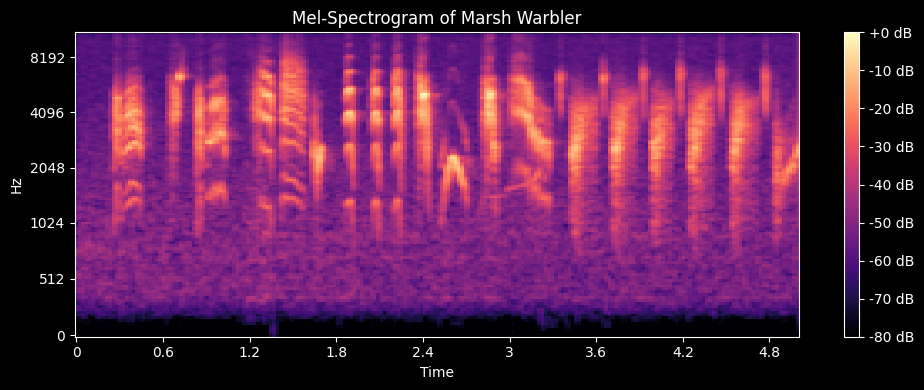

In [34]:

def plot_spectrogram(spectrogram, label, sr=22050):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram, x_axis='time', y_axis='mel', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel-Spectrogram of {label}')
    plt.tight_layout()
    plt.show()


# plot example chunk
spectrogram, label = dataset.__getitem__(14)
plot_spectrogram(rescale_spectrogram(spectrogram[0].numpy()), label)

In [35]:
# import the VAE and dataclasses that are defined in model.py
from model import VAE, VAEHyperparams, VAEOutput

In [36]:
def train_step(model, batch, optimizer, kl_weight=1.0):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    output = model(batch, kl_weight=kl_weight)

    # Backward pass
    output.loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    return output

In [23]:
hyperparameters = VAEHyperparams(
    latent_dim=128,
)

model = VAE(hyperparameters);

state_dict = torch.load('saved_models/epoch_100.pt', weights_only=True);

model.load_state_dict(state_dict)

<All keys matched successfully>

In [8]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100 

print(f"Training starting on device: {device}")

# def beta_ramp(epoch):
#     if epoch < 5:
#         return 0;
#     else:
#         return min(0.01, 0.01 * (epoch - 5) / 15);

for epoch in range(46,num_epochs):
    model.train()
    running_loss = 0.0
    running_mu = 0.0;
    running_std = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")
    
    for batch_idx, (spectrograms, labels) in enumerate(loop):
        spectrograms = spectrograms.to(device) 
        
        output = train_step(model, spectrograms, optimizer, kl_weight=0.0001);
        loss = output.loss.item()
        
        # Track statistics
        running_loss += loss
        running_mu += output.mu.detach().mean()
        running_std += output.std.detach().mean()
        
        # Update progress bar
        loop.set_postfix(loss=loss)
        
    # calculate average loss
    epoch_loss = running_loss / len(train_loader)
    epoch_mu = running_mu / len(train_loader)
    epoch_std = running_std / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Complete. Average Loss: {epoch_loss:.4f}, mu: {epoch_mu:.4f}, std: {epoch_std:.4f}\n")
    
    # Save a model checkpoint every 10 epochs
    if (epoch + 1) % 2 == 0:
        torch.save(model.state_dict(), f"saved_models/epoch_{epoch+1}.pt")

print("Training finished successfully!")

Training starting on device: cpu


Epoch [47/100]: 100%|██████████| 111/111 [01:57<00:00,  1.05s/it, loss=3.77]


Epoch [47/100] Complete. Average Loss: 3.9985, mu: -0.0558, std: 0.4544



Epoch [48/100]: 100%|██████████| 111/111 [02:14<00:00,  1.22s/it, loss=3.81]


Epoch [48/100] Complete. Average Loss: 3.9585, mu: -0.0586, std: 0.4439



...

Epoch [98/100] Complete. Average Loss: 3.3835, mu: -0.0630, std: 0.3221



Epoch [99/100]: 100%|██████████| 111/111 [02:08<00:00,  1.16s/it, loss=3.16]


Epoch [99/100] Complete. Average Loss: 3.3771, mu: -0.0626, std: 0.3220



Epoch [100/100]: 100%|██████████| 111/111 [02:11<00:00,  1.18s/it, loss=3.35]

Epoch [100/100] Complete. Average Loss: 3.3719, mu: -0.0629, std: 0.3222

Training finished successfully!


In [24]:

class_labels = []
chunk_features = []
chunk_spectrograms = [];

model.eval()
for index, (spectrograms, labels) in enumerate(train_loader):
    mu, sigma = model.encode(spectrograms);
    chunk_features += mu.detach();
    class_labels += labels;
    chunk_spectrograms += spectrograms;

features = np.array(chunk_features)

In [25]:


reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embeddings = reducer.fit_transform(chunk_features)

c:\development\Bird Song Project\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [26]:

plot_df = pd.DataFrame(embeddings, columns=['UMAP 1', 'UMAP 2'])
plot_df['Group'] = class_labels  # Add the labels back next to the 2D coordinates


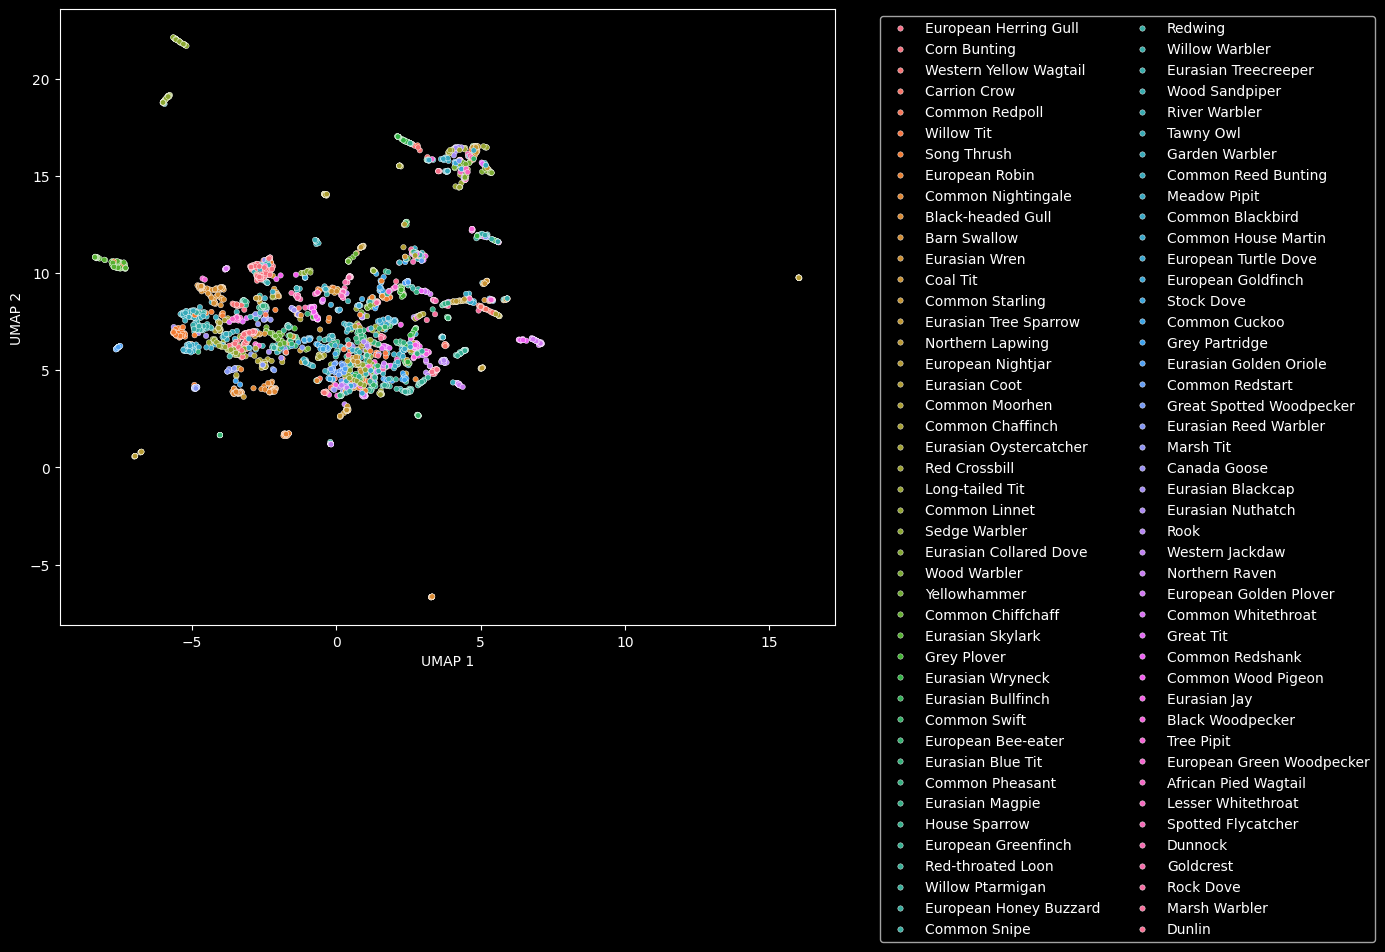

In [27]:
num_classes = plot_df['Group'].nunique()

# 2. Generate a custom palette with exactly that many unique colors
# 'husl' or 'hsv' are great for cycling through the full rainbow spectrum
large_palette = sns.color_palette("husl", num_classes)

plt.style.use('dark_background')
# 3. Use it in your scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df, 
    x='UMAP 1', 
    y='UMAP 2', 
    hue='Group', 
    palette=large_palette, # Pass the custom large palette here
    s=15
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2) # ncol=2 splits long legends into two columns

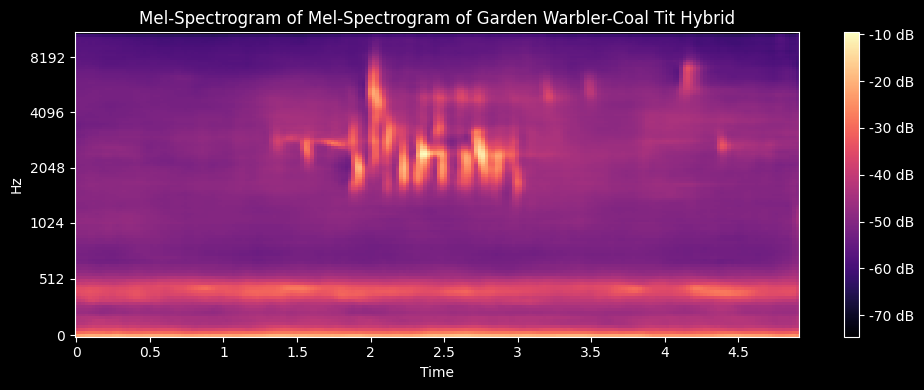

In [33]:
torch.no_grad()

bird = "Garden Warbler"
bird_2 = "Coal Tit"

bird_index = class_labels.index(bird);
bird_index_2 = class_labels.index(bird_2);

# reconstruction = model.decode((chunk_features[bird_index]+chunk_features[bird_index_2])*0.5)[:, :, :, 4:220]
reconstruction = model.decode(chunk_features[bird_index])[:, :, :, 4:220]
spec_db = rescale_spectrogram(reconstruction.detach().numpy()[0][0])

# output = model(chunk_spectrograms[bird_index].unsqueeze(0))
# spec_db = rescale_spectrogram(output.reconstruction.detach().numpy()[0][0])

spec_power = librosa.db_to_power(spec_db)

reconstructed_audio = librosa.feature.inverse.mel_to_audio(
    spec_power, 
    sr=22050, 
    n_fft=2048, 
    hop_length=512
)

# 5. Save it as a playable .wav file
sf.write("hybrid_bird_song.wav", reconstructed_audio, 22050)

plot_spectrogram(spec_db, f'Mel-Spectrogram of {bird}-{bird_2} Hybrid')

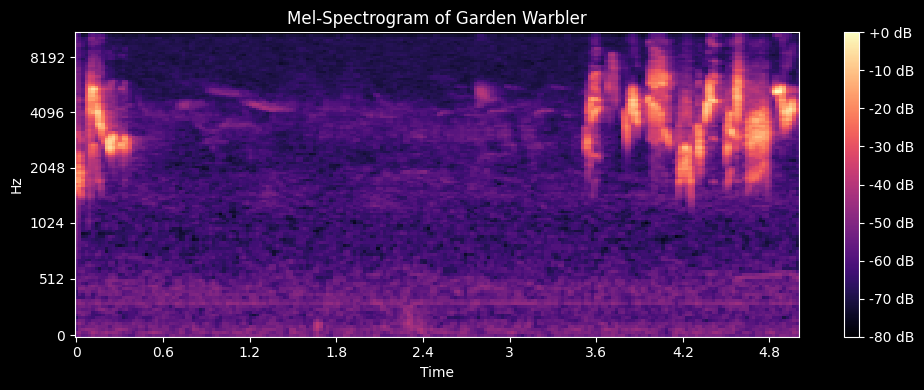

In [14]:
# print(class_labels[108])

# spectrogram, label = dataset.__getitem__(108)

plot_spectrogram(rescale_spectrogram(chunk_spectrograms[bird_index].numpy()[0]), class_labels[bird_index])

In [753]:
# output.std
# bird_index
embeddings[bird_index]

array([ 8.353187, 12.785246], dtype=float32)